# PubMedBERT (Axis 1) + MLP (Axis 2) : Improved

In [1]:
!pip install python-dotenv

In [2]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from pubmed_loader import PubMedQAData
from pubmedbert_preprocess import pubmedbert_preprocess

In [3]:
RANDOM_SEED = 11
MODEL_NAME  = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
DEVICE      = torch.device("xpu" if torch.xpu.is_available() else
               "cuda" if torch.cuda.is_available() else "cpu")

LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}

def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"All seeds set to {seed}")

set_all_seeds()
print(f"Using device: {DEVICE}")

All seeds set to 11
Using device: cpu


## 1. Data Loading

| Variant | Input to BERT |
|---------|--------------|
| **A** | `[question] + [context]` (plain baseline) |
| **B** | `[question] + [context] + MeSH terms` (enriched) |

In [4]:
data = PubMedQAData("data")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Variant A — plain question + context
train_enc_a, train_labels = pubmedbert_preprocess(data.train_set, tokenizer=tokenizer, use_mesh=False)
dev_enc_a,   dev_labels   = pubmedbert_preprocess(data.dev_set,   tokenizer=tokenizer, use_mesh=False)
test_enc_a,  test_labels  = pubmedbert_preprocess(data.test_set,  tokenizer=tokenizer, use_mesh=False)

# Variant B — question + context + MeSH terms
train_enc_b, _ = pubmedbert_preprocess(data.train_set, tokenizer=tokenizer, use_mesh=True)
dev_enc_b,   _ = pubmedbert_preprocess(data.dev_set,   tokenizer=tokenizer, use_mesh=True)
test_enc_b,  _ = pubmedbert_preprocess(data.test_set,  tokenizer=tokenizer, use_mesh=True)

print(f"train: {len(train_labels)} | dev: {len(dev_labels)} | test: {len(test_labels)}")
print("Train label dist:", np.bincount(train_labels.numpy()))
print("Dev   label dist:", np.bincount(dev_labels.numpy()))
print("Test  label dist:", np.bincount(test_labels.numpy()))

train: 450 | dev: 50 | test: 500
Train label dist: [249 152  49]
Dev   label dist: [27 17  6]
Test  label dist: [276 169  55]


## 2. Class Weights



In [5]:
counts        = np.bincount(train_labels.numpy())
counts_tensor = torch.FloatTensor(counts)
class_weights = 1.0 / counts_tensor
class_weights = class_weights / class_weights.sum() * 3   # normalise to n_classes

print(f"Class counts : {counts}  (yes / no / maybe)")
print(f"Class weights: {class_weights.numpy().round(4)}")

Class counts : [249 152  49]  (yes / no / maybe)
Class weights: [0.3886 0.6366 1.9748]


## 3. Pre-compute BERT Embeddings

BERT is fully frozen except the last 2 encoders. We run it **once** per split and cache both `[CLS]` and **mean-pooled** token embeddings.
- **[CLS]** : the standard classification token (Variants A & B).
- **Mean pooling** : average of all non-padding token hidden states (Variant C). Often captures richer sequence-level semantics than `[CLS]` alone.

In [6]:
def extract_embeddings(encodings, model, device, batch_size=32):
    """
    Returns:
      cls_vecs  : (N, 768) - [CLS] token embedding
      mean_vecs : (N, 768) - mean of all non-padding token embeddings
    """
    model.eval()
    all_cls, all_mean = [], []
    n = encodings["input_ids"].size(0)

    with torch.no_grad():
        for start in range(0, n, batch_size):
            end        = min(start + batch_size, n)
            input_ids  = encodings["input_ids"][start:end].to(device)
            attn_mask  = encodings["attention_mask"][start:end].to(device)
            outputs    = model(input_ids=input_ids, attention_mask=attn_mask)
            hidden     = outputs.last_hidden_state          # (B, T, 768)

            # CLS
            all_cls.append(hidden[:, 0, :].cpu())

            # Mean pool — zero out padding positions before averaging
            mask_expanded = attn_mask.unsqueeze(-1).float()            # (B, T, 1)
            sum_hidden    = (hidden * mask_expanded).sum(dim=1)        # (B, 768)
            token_counts  = mask_expanded.sum(dim=1).clamp(min=1e-9)   # (B, 1)
            all_mean.append((sum_hidden / token_counts).cpu())

    return torch.cat(all_cls, dim=0), torch.cat(all_mean, dim=0)


bert_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
for name, p in bert_model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name or "pooler" in name:
        p.requires_grad = True
    else:
        p.requires_grad = False
print("BERT loaded and frozen.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded and frozen.


In [7]:
print("Extracting Variant A (plain)...")
train_cls_a, train_mean_a = extract_embeddings(train_enc_a, bert_model, DEVICE)
dev_cls_a,   dev_mean_a   = extract_embeddings(dev_enc_a,   bert_model, DEVICE)
test_cls_a,  test_mean_a  = extract_embeddings(test_enc_a,  bert_model, DEVICE)

print("Extracting Variant B (+ MeSH)...")
train_cls_b, train_mean_b = extract_embeddings(train_enc_b, bert_model, DEVICE)
dev_cls_b,   dev_mean_b   = extract_embeddings(dev_enc_b,   bert_model, DEVICE)
test_cls_b,  test_mean_b  = extract_embeddings(test_enc_b,  bert_model, DEVICE)

print(f"  CLS  shape: {train_cls_a.shape}")
print(f"  Mean shape: {train_mean_a.shape}")
print("Done. BERT will not run again during MLP training.")

Extracting Variant A (plain)...
Extracting Variant B (+ MeSH)...
  CLS  shape: torch.Size([450, 768])
  Mean shape: torch.Size([450, 768])
Done. BERT will not run again during MLP training.


## 4. DataLoaders

In [8]:
BATCH_SIZE = 64

def make_loaders(train_emb, dev_emb, test_emb,
                 train_labels, dev_labels, test_labels,
                 batch_size=BATCH_SIZE):
    train_loader = DataLoader(TensorDataset(train_emb, train_labels), batch_size=batch_size, shuffle=True)
    dev_loader   = DataLoader(TensorDataset(dev_emb,   dev_labels),   batch_size=batch_size)
    test_loader  = DataLoader(TensorDataset(test_emb,  test_labels),  batch_size=batch_size)
    return train_loader, dev_loader, test_loader

# Variant A — CLS plain
train_loader_a, dev_loader_a, test_loader_a = make_loaders(
    train_cls_a, dev_cls_a, test_cls_a, train_labels, dev_labels, test_labels)

# Variant B — CLS + MeSH
train_loader_b, dev_loader_b, test_loader_b = make_loaders(
    train_cls_b, dev_cls_b, test_cls_b, train_labels, dev_labels, test_labels)

# Variant C — Mean pooling (plain input, different representation)
train_loader_c, dev_loader_c, test_loader_c = make_loaders(
    train_mean_a, dev_mean_a, test_mean_a, train_labels, dev_labels, test_labels)

print("DataLoaders ready.")

DataLoaders ready.


## 5. MLP Architecture

Wider network with BatchNorm for stable training: `768 → 512 → 128 → 3` to improve the model

In [9]:
class MLP(nn.Module):
    def __init__(self, input_dim=768):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        return self.network(x)

## 6. Training Loop

Improvements over the baseline:
- **Cosine annealing** LR scheduler for smoother convergence.
- **Early stopping** to prevent overfitting on the fixed BERT feature space.
- **Class-weighted loss** throughout.

In [10]:
def train_MLP(num_epochs, model, train_loader, dev_loader,
              learning_rate, class_weights=None, patience=7):

    loss_fn = nn.CrossEntropyLoss(
        weight=class_weights.to(next(model.parameters()).device)
        if class_weights is not None else None
    )
    if class_weights is not None:
        print(f"Using Weighted CrossEntropy: {class_weights.numpy().round(4)}")

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    all_train_losses, all_dev_losses = [], []
    best_dev_loss, best_state        = float("inf"), None
    patience_counter                 = 0

    for e in range(num_epochs):
        # Training
        model.train()
        train_losses, correct, total = [], 0, 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            output     = model(batch_X)
            batch_loss = loss_fn(output, batch_y)
            batch_loss.backward()
            optimizer.step()
            train_losses.append(batch_loss.item())
            correct += (output.argmax(1) == batch_y).sum().item()
            total   += batch_y.size(0)

        scheduler.step()
        mean_train = np.mean(train_losses)
        train_acc  = correct / total * 100
        all_train_losses.append(mean_train)

        # Validation
        model.eval()
        dev_losses, correct, total = [], 0, 0
        with torch.no_grad():
            for dev_X, dev_y in dev_loader:
                dev_X, dev_y = dev_X.to(DEVICE), dev_y.to(DEVICE)
                dev_out      = model(dev_X)
                dev_losses.append(loss_fn(dev_out, dev_y).item())
                correct += (dev_out.argmax(1) == dev_y).sum().item()
                total   += dev_y.size(0)

        mean_dev = np.mean(dev_losses)
        dev_acc  = correct / total * 100
        all_dev_losses.append(mean_dev)
        print(f"Epoch {e+1}/{num_epochs}  Train {mean_train:.4f}/{train_acc:.1f}%  "
              f"Val {mean_dev:.4f}/{dev_acc:.1f}%")

        if mean_dev < best_dev_loss:
            best_dev_loss    = mean_dev
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"  ✓ Best model saved (val_loss={best_dev_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Early stopping at epoch {e+1}")
                break

    model.load_state_dict(best_state)
    print(f"Restored best model (val_loss={best_dev_loss:.4f})")
    return model, all_train_losses, all_dev_losses

## 7. Evaluation Utilities

In [11]:
def training_curves(train_losses, dev_losses, title="Training curves"):
    plt.figure()
    plt.plot(train_losses, label="Training Loss")
    plt.plot(dev_losses,   label="Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()


def predict(model, loader):
    model.eval()
    gold_labs, pred_labs = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            gold_labs.extend(y.tolist())
            pred_labs.extend(model(X).argmax(1).cpu().tolist())
    return gold_labs, pred_labs


def evaluate(y_pred, y_true, split_name):
    acc       = accuracy_score(y_true, y_pred)
    f1_macro  = f1_score(y_true, y_pred, average="macro")
    pre_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n── {split_name} ──")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro-F1       : {f1_macro:.4f}")
    print(f"Macro-Precision: {pre_macro:.4f}")
    print("\nFull Classification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=["yes", "no", "maybe"],
                                zero_division=0))
    return acc, f1_macro, pre_macro


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["yes", "no", "maybe"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title); plt.tight_layout(); plt.show()

---
## Axis 1 - Text Representation

Three variants of what we feed into BERT before extracting the embedding:

| Variant | Representation |
|---------|---------------|
| **A** | `[CLS]` - plain question + context |
| **B** | `[CLS]` - question + context + MeSH terms |
| **C** | Mean pooling - plain question + context |

**Hypothesis (B):** MeSH terms are controlled biomedical vocabulary that may sharpen the embedding for domain-specific topics, especially helping the minority `maybe` class. However, they appear at the end of the 512-token window and may be truncated on long contexts.

**Hypothesis (C):** Mean pooling averages all token representations rather than relying on a single `[CLS]` vector, potentially capturing more of the context signal.

### Variant A - `[CLS]` plain

In [12]:
set_all_seeds()
NUM_EPOCHS    = 20
LEARNING_RATE = 2e-5

model_a = MLP(input_dim=768).to(DEVICE)
trained_model_a, train_losses_a, dev_losses_a = train_MLP(
    NUM_EPOCHS, model_a, train_loader_a, dev_loader_a, LEARNING_RATE,
    class_weights=class_weights
)

All seeds set to 11
Using Weighted CrossEntropy: [0.3886 0.6366 1.9748]
Epoch 1/20  Train 1.2861/28.9%  Val 1.0983/14.0%
  ✓ Best model saved (val_loss=1.0983)
Epoch 2/20  Train 1.1954/38.2%  Val 1.1034/30.0%
  No improvement. Patience 1/7
Epoch 3/20  Train 1.1151/33.3%  Val 1.1021/28.0%
  No improvement. Patience 2/7
Epoch 4/20  Train 1.0908/38.9%  Val 1.1012/28.0%
  No improvement. Patience 3/7
Epoch 5/20  Train 1.1055/37.8%  Val 1.0932/28.0%
  ✓ Best model saved (val_loss=1.0932)
Epoch 6/20  Train 1.1448/37.8%  Val 1.1006/26.0%
  No improvement. Patience 1/7
Epoch 7/20  Train 1.1193/38.7%  Val 1.1106/30.0%
  No improvement. Patience 2/7
Epoch 8/20  Train 1.0930/40.4%  Val 1.1192/26.0%
  No improvement. Patience 3/7
Epoch 9/20  Train 1.0913/38.2%  Val 1.1124/26.0%
  No improvement. Patience 4/7
Epoch 10/20  Train 1.0906/41.8%  Val 1.1093/30.0%
  No improvement. Patience 5/7
Epoch 11/20  Train 1.0695/39.6%  Val 1.1075/28.0%
  No improvement. Patience 6/7
Epoch 12/20  Train 1.0799/38.0

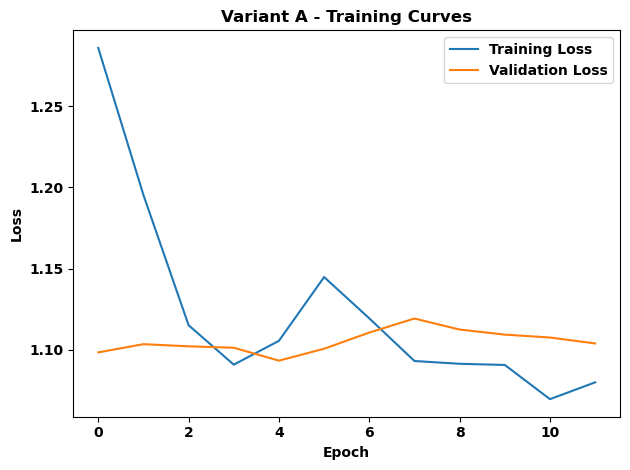

In [13]:
training_curves(train_losses_a, dev_losses_a, title="Variant A - Training Curves")


── Variant A - Test ([CLS] plain) ──
Accuracy       : 0.3580
Macro-F1       : 0.2597
Macro-Precision: 0.4296

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.56      0.54      0.55       276
          no       0.62      0.03      0.06       169
       maybe       0.11      0.44      0.17        55

    accuracy                           0.36       500
   macro avg       0.43      0.34      0.26       500
weighted avg       0.53      0.36      0.34       500



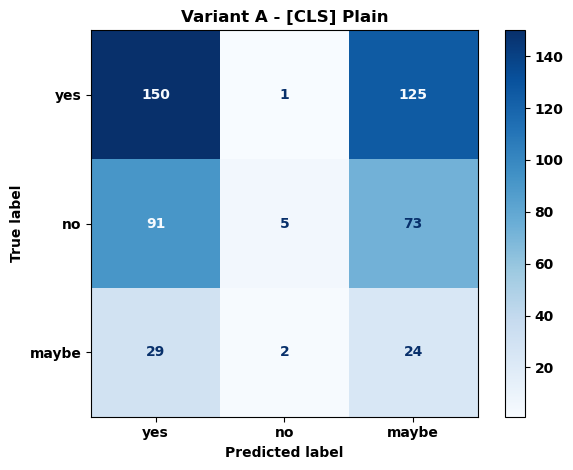

In [14]:
y_true_a, y_pred_a = predict(trained_model_a, test_loader_a)
acc_a, f1_a, pre_a = evaluate(y_pred_a, y_true_a, "Variant A - Test ([CLS] plain)")
plot_confusion_matrix(y_true_a, y_pred_a, title="Variant A - [CLS] Plain")

### Variant B - `[CLS]` + MeSH

In [15]:
set_all_seeds()

model_b = MLP(input_dim=768).to(DEVICE)
trained_model_b, train_losses_b, dev_losses_b = train_MLP(
    NUM_EPOCHS, model_b, train_loader_b, dev_loader_b, LEARNING_RATE,
    class_weights=class_weights
)

All seeds set to 11
Using Weighted CrossEntropy: [0.3886 0.6366 1.9748]
Epoch 1/20  Train 1.2553/28.2%  Val 1.0977/14.0%
  ✓ Best model saved (val_loss=1.0977)
Epoch 2/20  Train 1.2114/37.1%  Val 1.1026/34.0%
  No improvement. Patience 1/7
Epoch 3/20  Train 1.1376/32.9%  Val 1.1013/32.0%
  No improvement. Patience 2/7
Epoch 4/20  Train 1.1384/38.7%  Val 1.0973/30.0%
  ✓ Best model saved (val_loss=1.0973)
Epoch 5/20  Train 1.0741/38.2%  Val 1.0953/30.0%
  ✓ Best model saved (val_loss=1.0953)
Epoch 6/20  Train 1.1717/36.0%  Val 1.1029/28.0%
  No improvement. Patience 1/7
Epoch 7/20  Train 1.1304/38.9%  Val 1.1133/28.0%
  No improvement. Patience 2/7
Epoch 8/20  Train 1.0959/38.9%  Val 1.1168/30.0%
  No improvement. Patience 3/7
Epoch 9/20  Train 1.0883/39.8%  Val 1.1178/30.0%
  No improvement. Patience 4/7
Epoch 10/20  Train 1.1040/41.6%  Val 1.1143/28.0%
  No improvement. Patience 5/7
Epoch 11/20  Train 1.0670/39.6%  Val 1.1117/30.0%
  No improvement. Patience 6/7
Epoch 12/20  Train 1.0

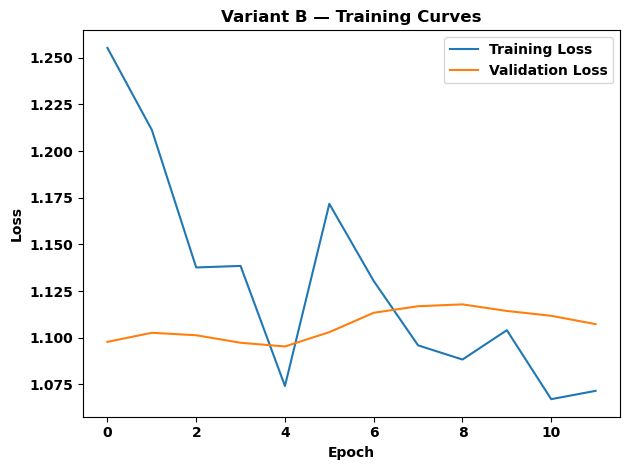

In [16]:
training_curves(train_losses_b, dev_losses_b, title="Variant B — Training Curves")


── Variant B - Test ([CLS] + MeSH) ──
Accuracy       : 0.3620
Macro-F1       : 0.2594
Macro-Precision: 0.3565

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.56      0.55      0.56       276
          no       0.40      0.02      0.04       169
       maybe       0.11      0.44      0.18        55

    accuracy                           0.36       500
   macro avg       0.36      0.34      0.26       500
weighted avg       0.46      0.36      0.34       500



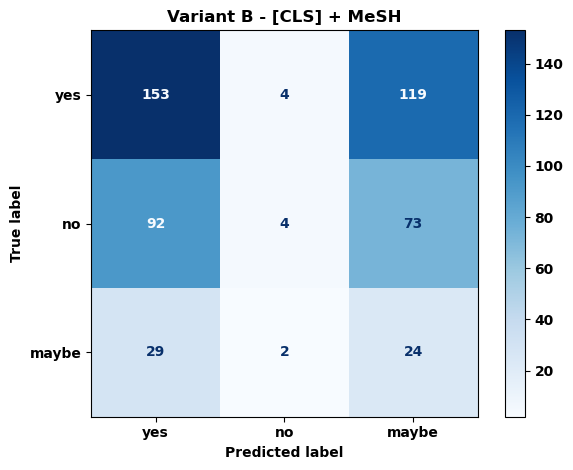

In [17]:
y_true_b, y_pred_b = predict(trained_model_b, test_loader_b)
acc_b, f1_b, pre_b = evaluate(y_pred_b, y_true_b, "Variant B - Test ([CLS] + MeSH)")
plot_confusion_matrix(y_true_b, y_pred_b, title="Variant B - [CLS] + MeSH")

---
## Summary: Variant A vs. Variant B

In [18]:
print(f"{'Variant':<40} {'Accuracy':>10} {'Macro-F1':>10} {'Macro-Prec':>12}")
print("-" * 75)
for name, acc, f1, pre in [
    ("Variant A  — Plain (question + context)",  acc_a, f1_a, pre_a),
    ("Variant B  — Enriched (+ MeSH terms)",     acc_b, f1_b, pre_b),
]:
    print(f"{name:<40} {acc:>10.4f} {f1:>10.4f} {pre:>12.4f}")

Variant                                    Accuracy   Macro-F1   Macro-Prec
---------------------------------------------------------------------------
Variant A  — Plain (question + context)      0.3580     0.2597       0.4296
Variant B  — Enriched (+ MeSH terms)         0.3620     0.2594       0.3565


---
## Side-by-side Confusion Matrices

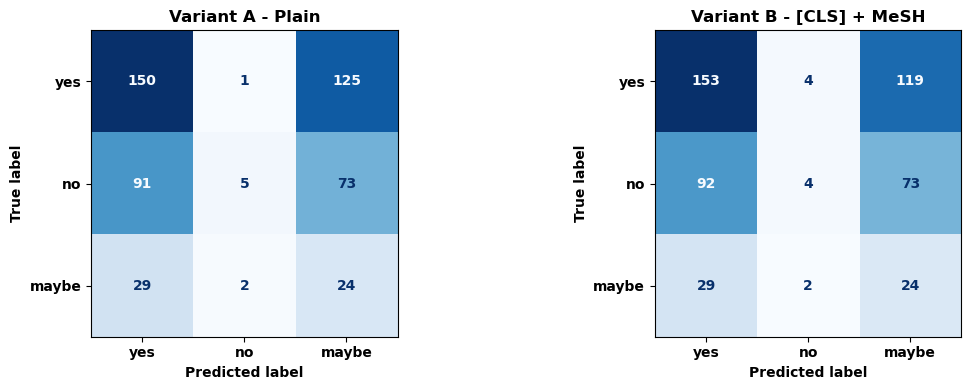

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_true_a, y_pred_a, "Variant A - Plain"),
    (axes[1], y_true_b, y_pred_b, "Variant B - [CLS] + MeSH"),
]:
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["yes", "no", "maybe"]
    )
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Variant C - Mean Pooling

In [20]:
set_all_seeds()

model_c = MLP(input_dim=768).to(DEVICE)
trained_model_c, train_losses_c, dev_losses_c = train_MLP(
    NUM_EPOCHS, model_c, train_loader_c, dev_loader_c, LEARNING_RATE,
    class_weights=class_weights
)

All seeds set to 11
Using Weighted CrossEntropy: [0.3886 0.6366 1.9748]
Epoch 1/20  Train 1.2164/32.4%  Val 1.0996/12.0%
  ✓ Best model saved (val_loss=1.0996)
Epoch 2/20  Train 1.1899/34.2%  Val 1.1073/50.0%
  No improvement. Patience 1/7
Epoch 3/20  Train 1.1544/32.4%  Val 1.1112/52.0%
  No improvement. Patience 2/7
Epoch 4/20  Train 1.1535/36.2%  Val 1.1075/40.0%
  No improvement. Patience 3/7
Epoch 5/20  Train 1.1049/34.0%  Val 1.1014/48.0%
  No improvement. Patience 4/7
Epoch 6/20  Train 1.1425/37.1%  Val 1.0922/36.0%
  ✓ Best model saved (val_loss=1.0922)
Epoch 7/20  Train 1.1508/37.3%  Val 1.0856/32.0%
  ✓ Best model saved (val_loss=1.0856)
Epoch 8/20  Train 1.0729/40.0%  Val 1.0840/28.0%
  ✓ Best model saved (val_loss=1.0840)
Epoch 9/20  Train 1.1019/37.6%  Val 1.0719/38.0%
  ✓ Best model saved (val_loss=1.0719)
Epoch 10/20  Train 1.0827/39.8%  Val 1.0754/28.0%
  No improvement. Patience 1/7
Epoch 11/20  Train 1.0879/37.3%  Val 1.0814/44.0%
  No improvement. Patience 2/7
Epoch 

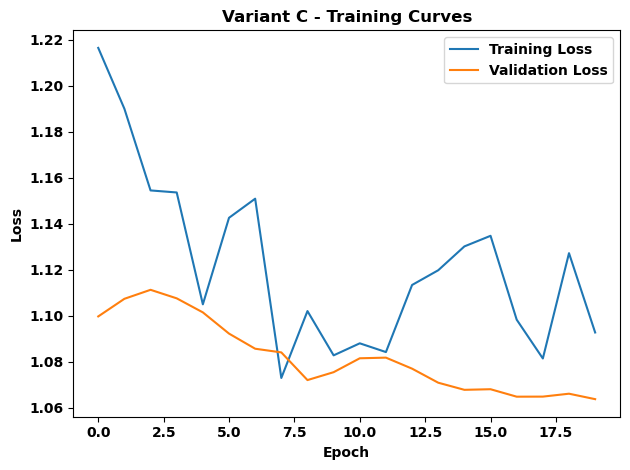

In [21]:
training_curves(train_losses_c, dev_losses_c, title="Variant C - Training Curves")


── Variant C - Test (Mean Pooling) ──
Accuracy       : 0.3580
Macro-F1       : 0.3085
Macro-Precision: 0.3684

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.59      0.46      0.52       276
          no       0.38      0.14      0.20       169
       maybe       0.13      0.53      0.21        55

    accuracy                           0.36       500
   macro avg       0.37      0.37      0.31       500
weighted avg       0.47      0.36      0.38       500



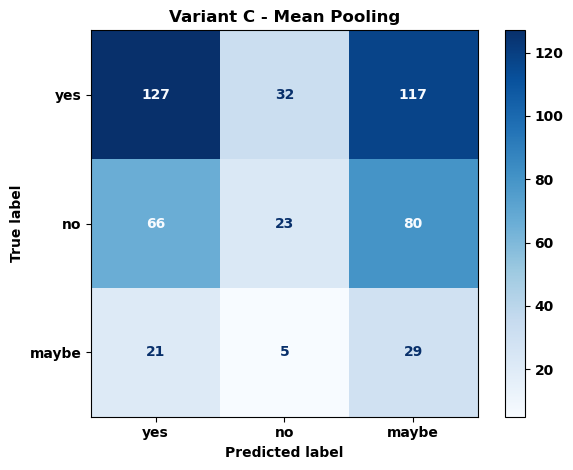

In [22]:
y_true_c, y_pred_c = predict(trained_model_c, test_loader_c)
acc_c, f1_c, pre_c = evaluate(y_pred_c, y_true_c, "Variant C - Test (Mean Pooling)")
plot_confusion_matrix(y_true_c, y_pred_c, title="Variant C - Mean Pooling")

---
## Summary - Axis 1: Text Representation

In [23]:
print(f"{'Variant':<45} {'Accuracy':>10} {'Macro-F1':>10} {'Macro-Prec':>12}")
print("-" * 80)
for name, acc, f1, pre in [
    ("Variant A — [CLS] plain (question + context)",    acc_a, f1_a, pre_a),
    ("Variant B — [CLS] + MeSH (enriched)",             acc_b, f1_b, pre_b),
    ("Variant C — Mean pooling (question + context)",   acc_c, f1_c, pre_c),
]:
    print(f"{name:<45} {acc:>10.4f} {f1:>10.4f} {pre:>12.4f}")

Variant                                         Accuracy   Macro-F1   Macro-Prec
--------------------------------------------------------------------------------
Variant A — [CLS] plain (question + context)      0.3580     0.2597       0.4296
Variant B — [CLS] + MeSH (enriched)               0.3620     0.2594       0.3565
Variant C — Mean pooling (question + context)     0.3580     0.3085       0.3684


### Side-by-side Confusion Matrices

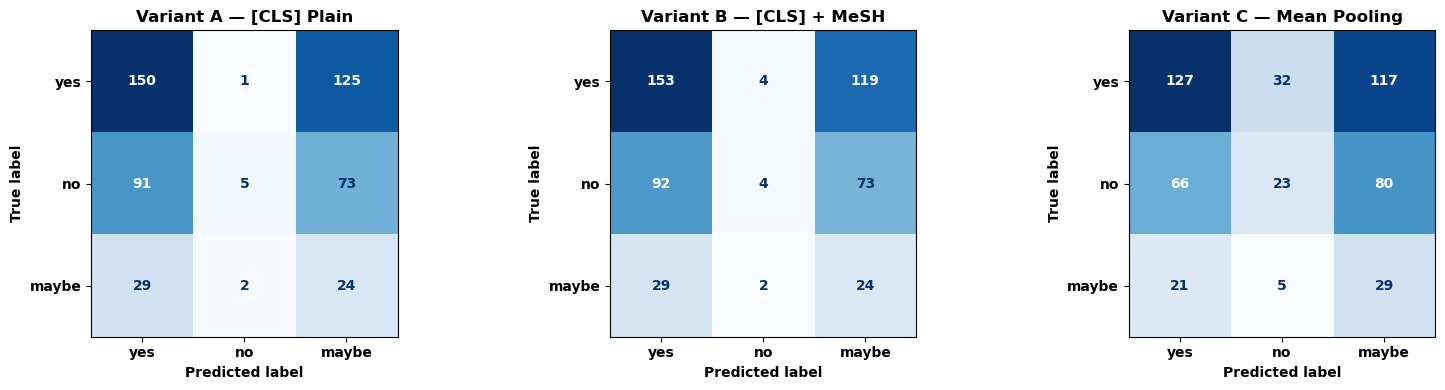

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_true_a, y_pred_a, "Variant A — [CLS] Plain"),
    (axes[1], y_true_b, y_pred_b, "Variant B — [CLS] + MeSH"),
    (axes[2], y_true_c, y_pred_c, "Variant C — Mean Pooling"),
]:
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["yes", "no", "maybe"])
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

---
## Variant D - CLS + Mean-Pool Concatenation

Rather than choosing between  and mean-pooling, we **concatenate** both into a single 1536-dim vector.
This retains the classification-optimised signal from  while enriching it with the distributional
context captured by mean-pooling. The MLP input dimension is doubled; everything else is identical.

**Hypothesis:** The combined representation will outperform both Variant A and C individually,
since each pooling strategy captures complementary information.


In [25]:
# Concatenate [CLS] and mean-pool vectors along the feature dimension
train_concat = torch.cat([train_cls_a, train_mean_a], dim=1)  # (N, 1536)
dev_concat   = torch.cat([dev_cls_a,   dev_mean_a],   dim=1)
test_concat  = torch.cat([test_cls_a,  test_mean_a],  dim=1)

print(f"Concatenated embedding shape: {train_concat.shape}")

train_loader_d, dev_loader_d, test_loader_d = make_loaders(
    train_concat, dev_concat, test_concat,
    train_labels, dev_labels, test_labels
)


Concatenated embedding shape: torch.Size([450, 1536])


In [26]:
set_all_seeds()

# Input dim is 1536 (768 CLS + 768 mean); everything else identical
model_d = MLP(input_dim=1536).to(DEVICE)
trained_model_d, train_losses_d, dev_losses_d = train_MLP(
    NUM_EPOCHS, model_d, train_loader_d, dev_loader_d, LEARNING_RATE,
    class_weights=class_weights
)


All seeds set to 11
Using Weighted CrossEntropy: [0.3886 0.6366 1.9748]
Epoch 1/20  Train 1.1841/32.7%  Val 1.1020/52.0%
  ✓ Best model saved (val_loss=1.1020)
Epoch 2/20  Train 1.2002/35.6%  Val 1.0978/56.0%
  ✓ Best model saved (val_loss=1.0978)
Epoch 3/20  Train 1.1072/40.2%  Val 1.0955/56.0%
  ✓ Best model saved (val_loss=1.0955)
Epoch 4/20  Train 1.1377/35.8%  Val 1.0890/48.0%
  ✓ Best model saved (val_loss=1.0890)
Epoch 5/20  Train 1.0882/43.6%  Val 1.0875/32.0%
  ✓ Best model saved (val_loss=1.0875)
Epoch 6/20  Train 1.1091/43.6%  Val 1.0849/34.0%
  ✓ Best model saved (val_loss=1.0849)
Epoch 7/20  Train 1.0781/43.6%  Val 1.0766/30.0%
  ✓ Best model saved (val_loss=1.0766)
Epoch 8/20  Train 1.0924/41.3%  Val 1.0748/28.0%
  ✓ Best model saved (val_loss=1.0748)
Epoch 9/20  Train 1.0799/45.3%  Val 1.0743/30.0%
  ✓ Best model saved (val_loss=1.0743)
Epoch 10/20  Train 1.0318/45.8%  Val 1.0808/28.0%
  No improvement. Patience 1/7
Epoch 11/20  Train 1.0287/47.6%  Val 1.0819/26.0%
  No 

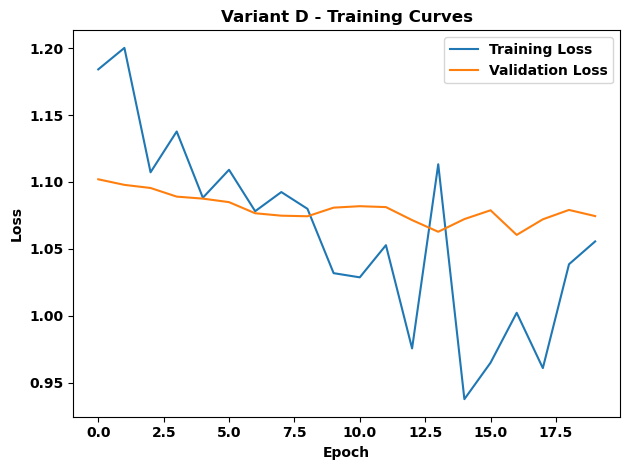

In [27]:
training_curves(train_losses_d, dev_losses_d, title="Variant D - Training Curves")



── Variant D - Test (CLS + Mean-Pool concat) ──
Accuracy       : 0.3940
Macro-F1       : 0.3499
Macro-Precision: 0.3762

Full Classification Report:
              precision    recall  f1-score   support

         yes       0.62      0.42      0.50       276
          no       0.41      0.38      0.40       169
       maybe       0.11      0.29      0.15        55

    accuracy                           0.39       500
   macro avg       0.38      0.37      0.35       500
weighted avg       0.49      0.39      0.43       500



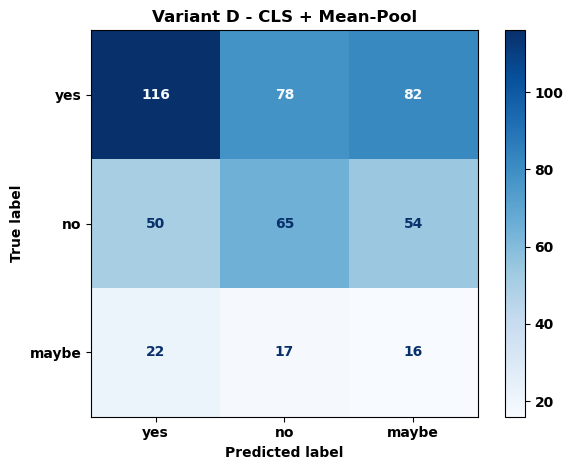

In [28]:
y_true_d, y_pred_d = predict(trained_model_d, test_loader_d)
acc_d, f1_d, pre_d = evaluate(y_pred_d, y_true_d, "Variant D - Test (CLS + Mean-Pool concat)")
plot_confusion_matrix(y_true_d, y_pred_d, title="Variant D - CLS + Mean-Pool")


---
## Final Summary - All Variants


In [29]:
print(f"{chr(39)*0}{'Variant':<45} {'Accuracy':>10} {'Macro-F1':>10} {'Macro-Prec':>12}")
print("-" * 80)
for name, acc, f1, pre in [
    ("Variant A — [CLS] plain",              acc_a, f1_a, pre_a),
    ("Variant B — [CLS] + MeSH",             acc_b, f1_b, pre_b),
    ("Variant C — Mean pooling",             acc_c, f1_c, pre_c),
    ("Variant D — CLS + Mean-Pool concat",   acc_d, f1_d, pre_d),
]:
    print(f"{name:<45} {acc:>10.4f} {f1:>10.4f} {pre:>12.4f}")


Variant                                         Accuracy   Macro-F1   Macro-Prec
--------------------------------------------------------------------------------
Variant A — [CLS] plain                           0.3580     0.2597       0.4296
Variant B — [CLS] + MeSH                          0.3620     0.2594       0.3565
Variant C — Mean pooling                          0.3580     0.3085       0.3684
Variant D — CLS + Mean-Pool concat                0.3940     0.3499       0.3762
